# Rockall Trough glider section - EOF analysis

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append(r'../') # Add this line at the beginner of each notebook to be able to load local functions 
import src.features.RT_functions as rtf
import src.features.RT_data as rtd
import src.features.matfile_functions as matlab_fct
import src.features.RT_transport as rtt
import src.features.RT_EOF_functions as rt_eof
import src.set_paths as sps
import src.RT_parameters as rtp
import src.features.RT_visualise as rtv

C:\Users\sa07kb\Projects\Rockall_Trough_Transports\notebooks\..\src\features\RT_transport.py:9: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
from matplotlib import pyplot as plt
import dask
import datetime
import gsw
import numpy as np
import pandas as pd
import mat73
import xarray as xr
from pathlib import Path
import xeofs as xe
from eofs.xarray import Eof
import warnings
warnings.filterwarnings('ignore')
xr.set_options(display_expand_attrs=False)
%matplotlib inline

# Set in- and output path

In [3]:
date_str_start = '2020'
date_str_end = '2025'
fn_version = 'v0'
script_name = f"2.3_compare_eof_tools"

# output figures
fig_out_path = (sps.local_fig_dir/f"{script_name}")
Path(fig_out_path).mkdir(parents=True, exist_ok=True)

In [4]:
# mooring intput data
fn_in_version = 'v1'
fn_base_grid = "Rockall_Trough_mooring_gridded_TSUV"
fn_base_stack = "Rockall_Trough_mooring_stacked_TSUV"
date_str_start_moor = '201407'
date_str_end_moor = '202407'

RT_mooring_fn = f"{fn_base_grid}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"
file_name_in_stack = f"{fn_base_stack}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"

# transport input data
fn_in_version = 'v0'
fn_base_grid = "Rockall_Trough_transport_3D_TIME_series"
RT_transp_grid_fn = f"{fn_base_grid}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"

prep_RT_mooring_data_path = (sps.local_data_dir/f'0.0_Rockall_Trough_moorings_data_prep_{date_str_start_moor}_{date_str_end_moor}_v0/')
RT_transport_data_path_v0 = (sps.local_data_dir/f'1.0_Rockall_Trough_transports_{date_str_start_moor[:-2]}_{date_str_end_moor[:-2]}_v0/')
RT_transport_data_path_v1 = (sps.local_data_dir/f'3.0_Rockall_Trough_transports_{date_str_start_moor[:-2]}_{date_str_end_moor[:-2]}_v1/')

# Load data

In [5]:
#load glider
ds_glider_mat = matlab_fct.load_glider_mat(sps.glider_data_path,sps.glider_fn)
ds_glider_mat_nan = rt_eof.add_nan_glider_sections(ds_glider_mat,dim='time')

In [6]:
ds_glider = ds_glider_mat
ds_glider_nan = ds_glider_mat_nan

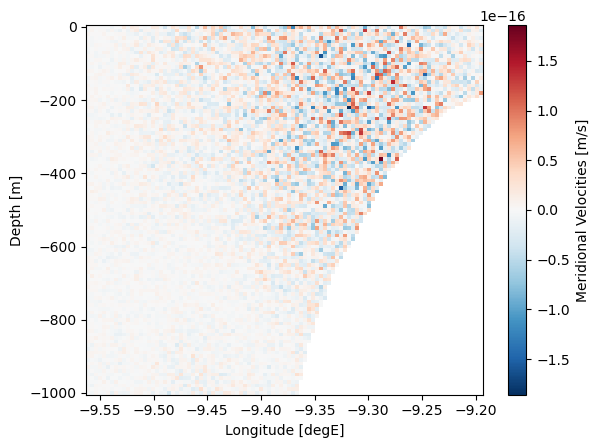

In [7]:
test_vcur = ds_glider.vcur 
test_mean = test_vcur.mean('time')
test_vcur = test_vcur-test_mean
test_vcur.mean('time').plot(x='lon')

# EOF analysis using xeof

In [8]:
model = xe.single.EOF(n_modes=5, 
                      standardize=False,use_coslat=False,check_nans=True)
model.fit(test_vcur, dim="time")
expvar = model.explained_variance_ratio()
components = model.components()
scores = model.scores()

In [9]:
n_boot = 1000

bs = xe.validation.EOFBootstrapper(n_bootstraps=n_boot)
bs.fit(model)
bs_expvar = bs.explained_variance()
ci_expvar = bs_expvar.quantile([0.025, 0.975], "n")  # 95% confidence intervals

q025 = ci_expvar.sel(quantile=0.025)
q975 = ci_expvar.sel(quantile=0.975)

is_significant = q025 - q975.shift({"mode": -1}) > 0
n_significant_modes = (
    is_significant.where(is_significant is True).cumsum(skipna=False).max().fillna(0)
)
print("{:} modes are significant at alpha=0.05".format(n_significant_modes.values))

100%|███████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:50<00:00,  5.86it/s]


0.0 modes are significant at alpha=0.05


In [10]:
ci_components = bs.components().quantile([0.025, 0.975], "n")
ci_scores = bs.scores().quantile([0.025, 0.975], "n")

is_sig_comps = np.sign(ci_components).prod("quantile") > 0

In [11]:
model.explained_variance()

<xarray.DataArray 'explained_variance' (mode: 5)> Size: 40B
array([86.78851931, 16.80950708, 12.02248841,  9.71665737,  8.17050502])
Coordinates:
  * mode     (mode) int64 40B 1 2 3 4 5
Attributes: (15)

In [12]:
model.explained_variance_ratio()

<xarray.DataArray 'explained_variance_ratio' (mode: 5)> Size: 40B
array([0.54187544, 0.10495235, 0.07506397, 0.06066722, 0.05101361])
Coordinates:
  * mode     (mode) int64 40B 1 2 3 4 5
Attributes: (15)

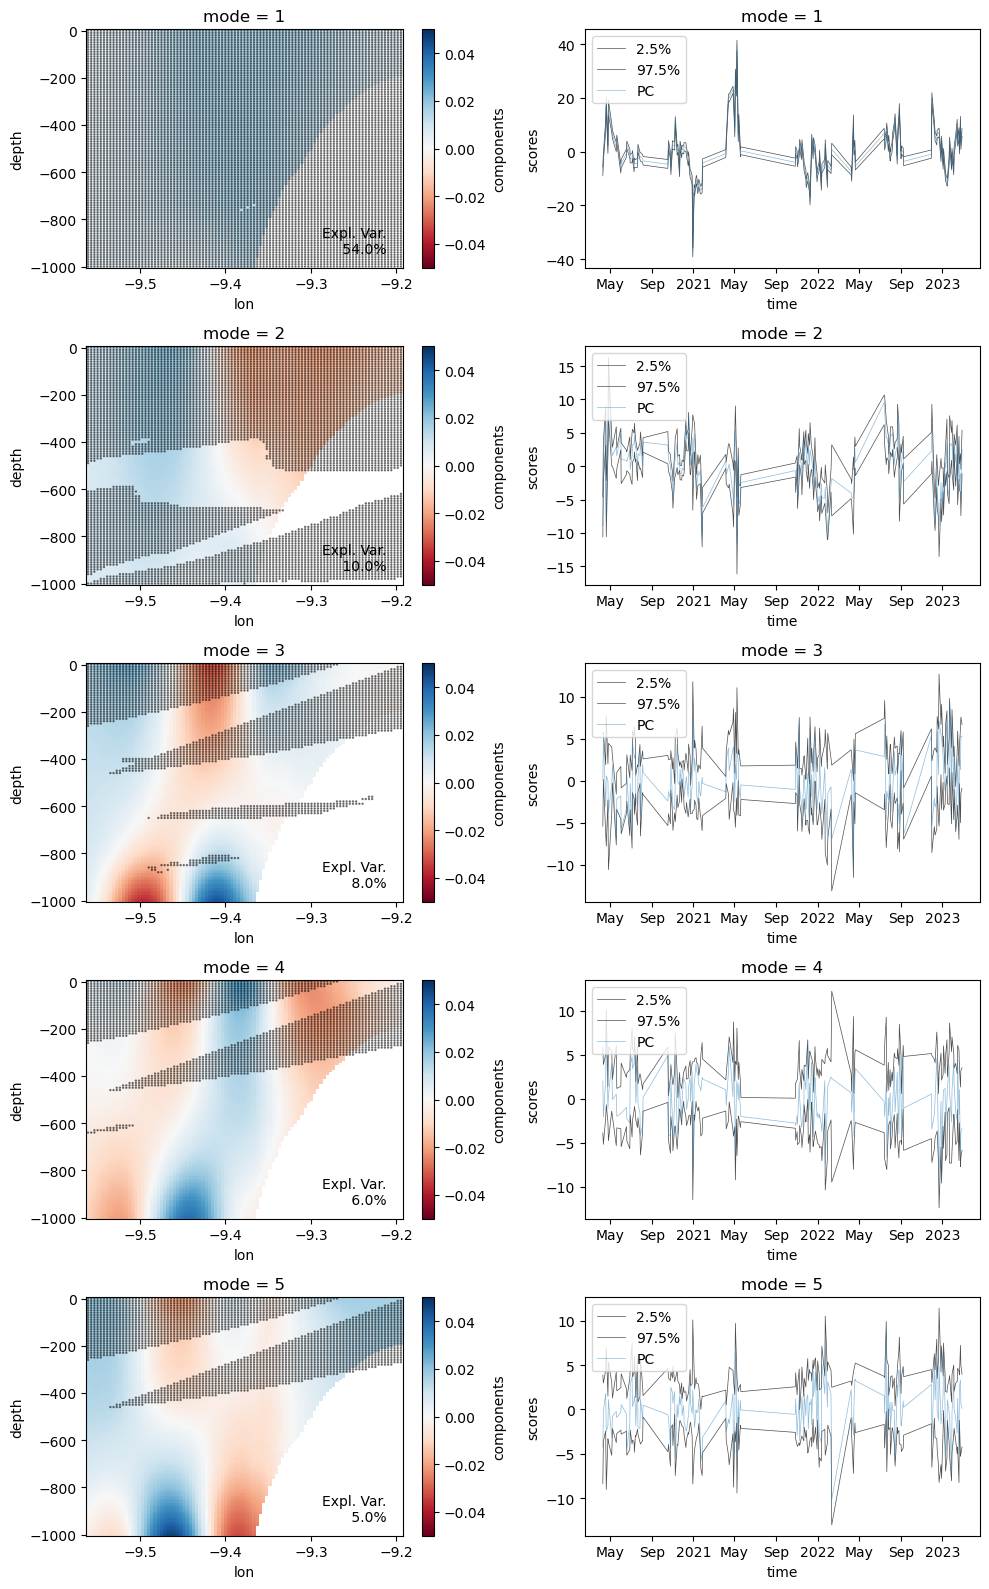

In [13]:
kwargs = {"cmap": "RdBu", "vmin": -0.05, "vmax": 0.05}
lons, z = np.meshgrid(is_sig_comps.lon.values, is_sig_comps.depth.values)

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 16))
gs = GridSpec(5, 2)
ax1 = [fig.add_subplot(gs[i, 0]) for i in range(5)]
ax2 = [fig.add_subplot(gs[i, 1]) for i in range(5)]

for i, (a1, a2) in enumerate(zip(ax1, ax2)):
    components.isel(mode=i).plot(ax=a1,x='lon', **kwargs)
    a1.scatter(
        lons,
        z,
        is_sig_comps.isel(mode=i).values * 0.5,
        color="k",
        alpha=0.5,
    )
    a1.text(0.95, 0.05,f'Expl. Var.\n {(expvar * 100).round(0).values[i]:02.1f}%',
                    transform=a1.transAxes, 
                     verticalalignment='bottom',horizontalalignment='right')
    ci_scores.isel(mode=i, quantile=0).plot(ax=a2, color=".3", lw=".5", label="2.5%")
    ci_scores.isel(mode=i, quantile=1).plot(ax=a2, color=".3", lw=".5", label="97.5%")
    scores.isel(mode=i).plot(ax=a2, lw=".5", alpha=0.5, label="PC")
    a2.legend(loc=2)

plt.tight_layout()
plt.savefig(fig_out_path/"xeof_analysis_with_bootstrap.jpg")

### using rt_eof function which uses xeofs

In [14]:
# recreate using EOFs and scores
v_rec_EOF = -1*model.components()*model.scores()
v_rec_EOF['x']=test_vcur.x
v_rec_EOF['lat']=test_vcur.lat
v_rec_EOF = v_rec_EOF.cumsum('mode')

In [15]:
ds_glider['Q']=(rt_eof.calc_transport(test_vcur+test_mean))
ds_glider['Q_rec_EOF']=rt_eof.calc_transport(v_rec_EOF-test_mean)

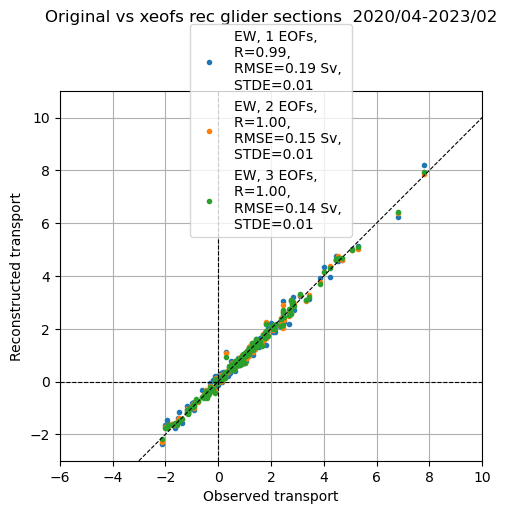

In [16]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.Q,
                  ds_glider.Q_rec_EOF,
                  3,axs,var_str='Q',t_dim='time')
plt.title(f'Original vs xeofs rec glider sections  {rtv.date_str_func(ds_glider,dim='time')}', pad=50)

plt.savefig(fig_out_path/"xeof_Q_rec_using_eofs_vs_observed.jpg")

# Perform eof now using eofs

In [17]:
# time needs to be first dimension
test_vcur = test_vcur.transpose('time', 'lon', 'depth')

In [18]:
# Create an EOF solver to do the EOF analysis. 
solver = Eof(test_vcur,center=False)

# Retrieve the nmodes leading EOF, expressed as the covariance between the leading PC
# time series and the input anomalies at each grid point.
nmodes = 5
eof1_co = solver.eofsAsCovariance(neofs=nmodes)

# Retreive nmodes leading EOFs scaled by the square-root of their eigenvalues
# (eofscaling = 0, un-scaled is default), 
eof1 = solver.eofs(neofs=nmodes, eofscaling=0)

# Retreive nmodes leading PCs (default)
pc1 = solver.pcs(npcs=nmodes, pcscaling=0)

# The fractional variance represented by the first nmodes eigenvalues:
variance_fractions = solver.varianceFraction(neigs=nmodes)
print(variance_fractions)
# Reconstructed data field based on a subset of EOFs.
# Reconstruct the input field using nmodes EOFs:

for i in range(nmodes):
    if i==0:
        reconstruction = solver.reconstructedField(i+1)
    else:
        reconstruction = xr.concat([reconstruction,
                                    solver.reconstructedField(i+1)],
                                   dim='mode')

<xarray.DataArray 'variance_fractions' (mode: 5)> Size: 40B
array([0.54187544, 0.10495235, 0.07506397, 0.06066722, 0.05101361])
Coordinates:
  * mode     (mode) int64 40B 0 1 2 3 4
Attributes: (1)


In [19]:
solver.eigenvalues(neigs=nmodes)

<xarray.DataArray 'eigenvalues' (mode: 5)> Size: 40B
array([86.78851931, 16.80950708, 12.02248841,  9.71665737,  8.17050502])
Coordinates:
  * mode     (mode) int64 40B 0 1 2 3 4
Attributes: (1)

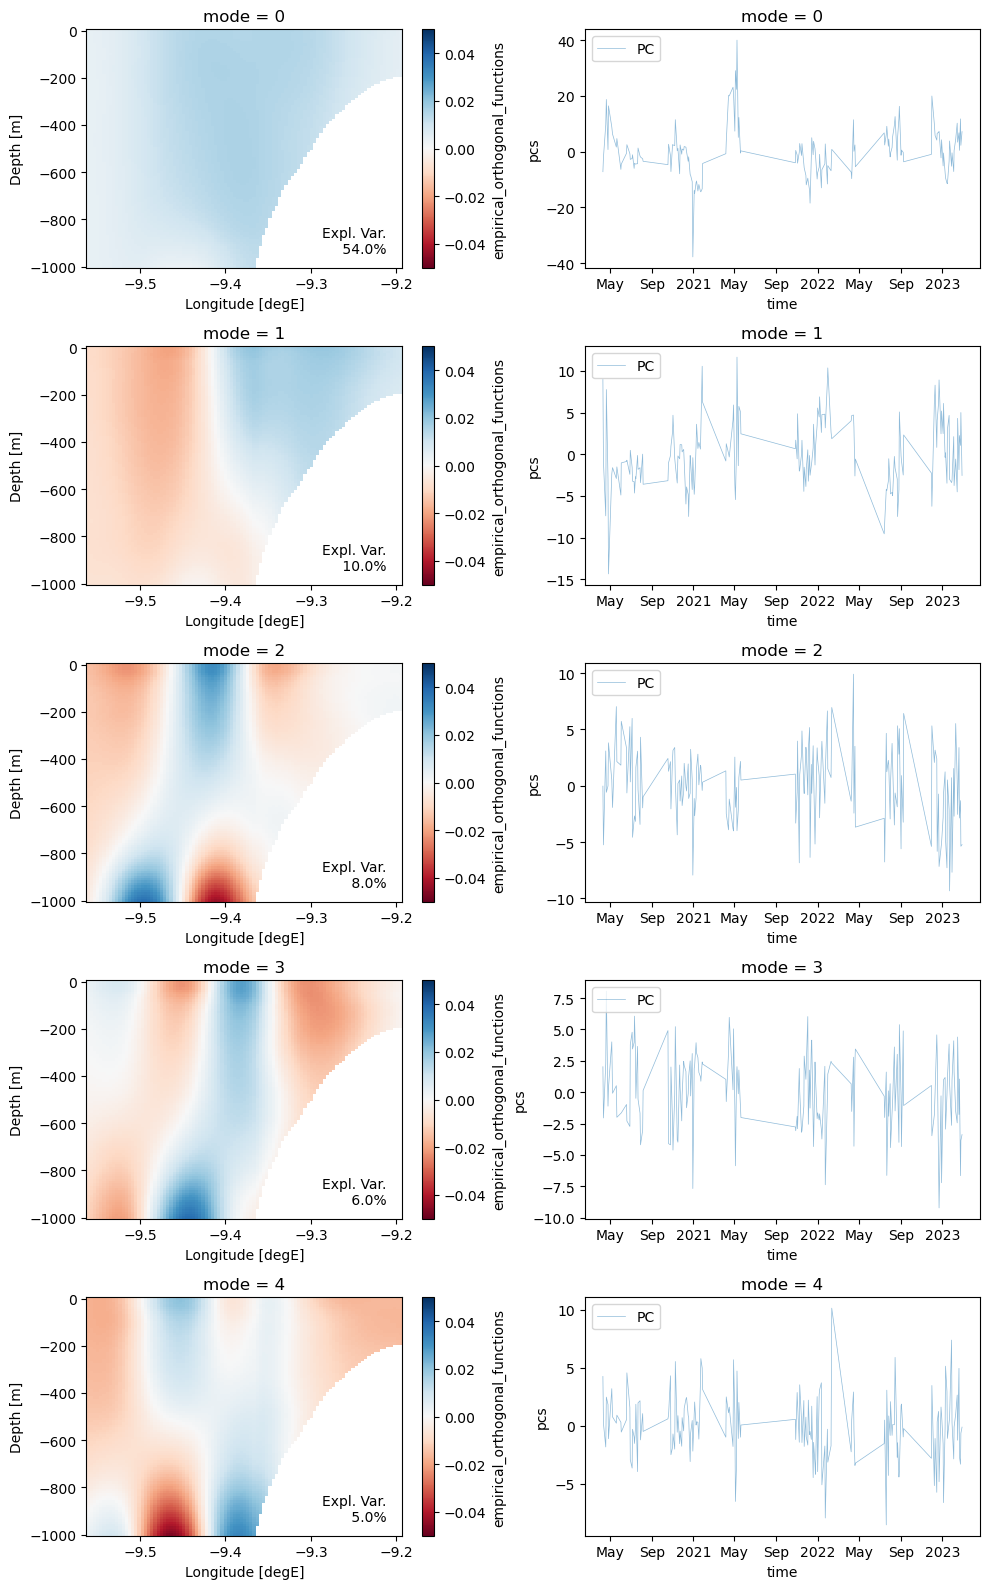

In [20]:
kwargs = {"cmap": "RdBu", "vmin": -0.05, "vmax": 0.05}

fig = plt.figure(figsize=(10, 16))
gs = GridSpec(5, 2)
ax1 = [fig.add_subplot(gs[i, 0]) for i in range(5)]
ax2 = [fig.add_subplot(gs[i, 1]) for i in range(5)]

for i, (a1, a2) in enumerate(zip(ax1, ax2)):
    eof1.isel(mode=i).plot(ax=a1,x='lon', **kwargs)
    a1.text(0.95, 0.05,f'Expl. Var.\n {(variance_fractions * 100).round(0).values[i]:02.1f}%',
                    transform=a1.transAxes, 
                     verticalalignment='bottom',horizontalalignment='right')
    pc1.isel(mode=i).plot(ax=a2, lw=".5", alpha=0.5, label="PC")
    a2.legend(loc=2)

plt.tight_layout()
plt.savefig(fig_out_path/"eofs_analysis_no_sign_test_available.jpg")

### using rt_eof function which uses xeofs

In [21]:
ds_glider['Q_rec_EOF_2']=rt_eof.calc_transport(reconstruction+test_mean)

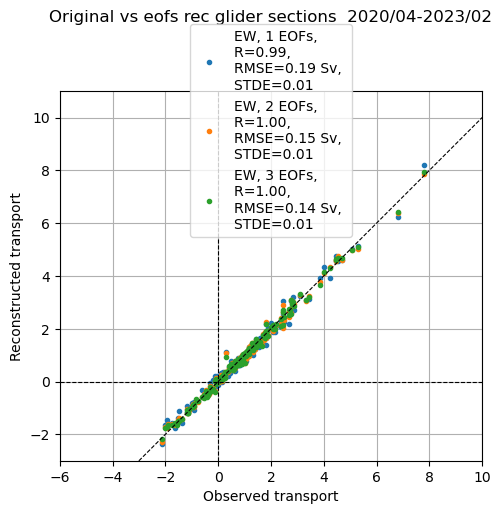

In [22]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.Q,
                  ds_glider.Q_rec_EOF_2,
                  3,axs,var_str='Q',t_dim='time')
plt.title(f'Original vs eofs rec glider sections  {rtv.date_str_func(ds_glider,dim='time')}', pad=50)
plt.savefig(fig_out_path/"eofs_Q_rec_using_eofs_vs_observed.jpg")

Text(0.5, 1.0, 'Original vs xeofs rec glider sections  2020/04-2023/02')

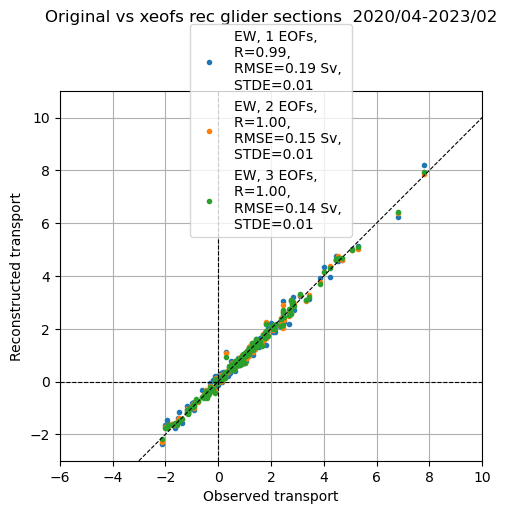

In [23]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.Q,
                  ds_glider.Q_rec_EOF,
                  3,axs,var_str='Q',t_dim='time')
plt.title(f'Original vs xeofs rec glider sections  {rtv.date_str_func(ds_glider,dim='time')}', pad=50)